<a href="https://colab.research.google.com/github/sadaf-iqbal17/Pytorch/blob/main/Basic_Neura_Network_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn    #torch has neural network library thing  we are using that here
import torch.nn.functional as F    # this will allow  us to move our data forward in the function

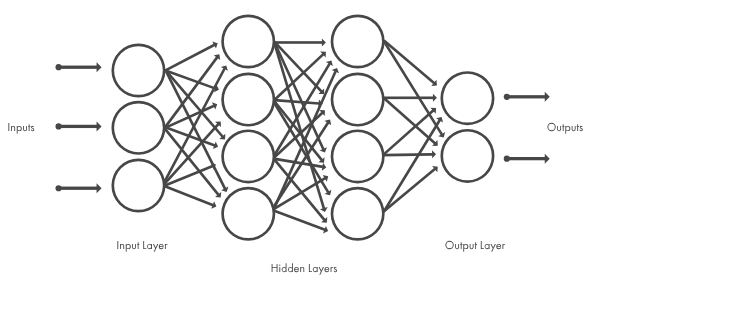

**Create a model class that inherits nn.Model**

In [10]:
class Model(nn.Module):
  # This line defines a new class called 'Model'.
  # It inherits from 'nn.Module', which is the base class for all neural network modules in PyTorch.
  # This means our 'Model' class will have all the functionalities of a PyTorch neural network.

  # These comments describe the overall structure of our neural network:
  # - input layer: Takes 4 features (Sepal length, Sepal width, Petal length, Petal width).
  # - hidden layer 1 (h1): An intermediate layer with a certain number of neurons.
  # - hidden layer 2 (h2): Another intermediate layer.
  # - output layer: Produces 3 outputs, corresponding to the three types of iris flowers we want to classify.

  def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
    # This is the constructor method, called when you create a new instance of the 'Model' class.
    # 'self' refers to the instance of the class being created.
    # 'in_features': The number of input features (4 for our iris dataset).
    # 'h1': The number of neurons in the first hidden layer (we chose 8).
    # 'h2': The number of neurons in the second hidden layer (we chose 9).
    # 'out_features': The number of output features (3 for the three iris classes).

    super().__init__()
    # This line calls the constructor of the parent class (nn.Module).
    # It's essential to properly initialize the base neural network functionality.

    self.fc1 = nn.Linear(in_features, h1)
    # This creates the first 'fully connected' layer (fc1).
    # 'nn.Linear' creates a linear transformation (y = xA^T + b).
    # It takes 'in_features' as input and produces 'h1' outputs.
    # This connects the input layer to the first hidden layer.

    self.fc2 = nn.Linear(h1, h2)
    # This creates the second fully connected layer (fc2).
    # It takes the output from fc1 (which has 'h1' features) and produces 'h2' outputs.
    # This connects the first hidden layer to the second hidden layer.

    self.out = nn.Linear(h2, out_features)
    # This creates the output layer.
    # It takes the output from fc2 (which has 'h2' features) and produces 'out_features' (3) outputs.
    # This connects the second hidden layer to the final output layer.
    # 'fc' stands for fully connected, meaning every neuron in the previous layer is connected to every neuron in the current layer.

  # This method defines how data flows forward through the neural network.
  def forward(self, x):
    # 'x' is the input data (e.g., a batch of flower features).

    x = F.relu(self.fc1(x))
    # First, the input 'x' is passed through the first fully connected layer (self.fc1).
    # The output of self.fc1(x) is then passed through the ReLU (Rectified Linear Unit) activation function.
    # ReLU function: if the output is less than 0, it becomes 0; otherwise, it remains unchanged.
    # This introduces non-linearity, allowing the model to learn complex patterns.

    x = F.relu(self.fc2(x))
    # The output from the previous step is now passed through the second fully connected layer (self.fc2).
    # Again, the result is processed by the ReLU activation function.

    x = self.out(x)
    # Finally, the output from the second hidden layer is passed through the output layer (self.out).
    # This layer produces the raw scores (logits) for each of the three iris classes.

    return x
    # The method returns the final output of the network.

In [11]:
# Create a manual seed because neural network initialization involves randomization.
# This ensures that if you run the code multiple times, you get the same 'random' starting weights for reproducibility.
torch.manual_seed(41)   # 41 is just a chosen random number to seed the random number generator.

# Create an instance of the Model class we defined earlier.
# This initializes our neural network with the specified input, hidden, and output layer sizes.
# The 'model' object now contains all the layers (fc1, fc2, out) and their initial weights.
model = Model()

Training the Model
**bold text**


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [19]:
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
my_df = pd.read_csv(url)
my_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [24]:
#Change last column from strings to integers
my_df['species'] = my_df['species'].replace('setosa', 0.0)
my_df['species'] = my_df['species'].replace('nersicolor', 1.0)
my_df['species'] = my_df['species'].replace('virginica', 2.0)
my_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [25]:
#Train Test Split  Set X , y
X = my_df.drop('species', axis=1)  #axis is set to 1 because it is a column
# now we will drop the last column because it is output
y=my_df['species']

In [ ]:
#Convert these to numpy arrays
X= X.values
y=y.values

In [26]:
from sklearn.model_selection import train_test_split

In [28]:
#Train Test Split
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=41 )

In [32]:
X_train = torch.FloatTensor(X_train.values)
X_test = torch.FloatTensor(X_test.values)

TypeError: new(): data must be a sequence (got builtin_function_or_method)